In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/allupravallikadevi/sample-store-data/Sample - Superstore.csv


In [2]:
import pandas as pd

# Load the data
df = pd.read_csv('/kaggle/input/datasets/allupravallikadevi/sample-store-data/Sample - Superstore.csv', encoding='latin1')

# Convert 'Order Date' to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Select Sales and Date, then group by month
sales_data = df[['Order Date', 'Sales']].copy()
sales_data = sales_data.set_index('Order Date')
y = sales_data['Sales'].resample('MS').sum() # 'MS' stands for Month Start

In [3]:
# 1. Convert 'Order Date' and 'Ship Date' to datetime objects
# We use errors='coerce' to turn any unparseable dates into NaT (Not a Time)
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], errors='coerce')

# 2. Check if any dates failed to convert
missing_dates = df['Order Date'].isnull().sum()
if missing_dates > 0:
    print(f"Warning: {missing_dates} rows had invalid dates and were set to NaT.")
    # Usually, for time series, we drop rows with missing dates
    df = df.dropna(subset=['Order Date'])

# 3. Sort by date (Essential for Time Series)
df = df.sort_values('Order Date')

# 4. Create extra features that help with Demand Analysis
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Day_of_Week'] = df['Order Date'].dt.day_name()

# Display the first few rows to confirm
df[['Order Date', 'Year', 'Month', 'Day_of_Week']].head()

,Order Date,Year,Month,Day_of_Week
7980,2014-01-03,2014,1,Friday
739,2014-01-04,2014,1,Saturday
740,2014-01-04,2014,1,Saturday
741,2014-01-04,2014,1,Saturday
1759,2014-01-05,2014,1,Sunday


In [4]:
# 1. Set the 'Order Date' as the index (required for resampling)
df_indexed = df.set_index('Order Date')

# 2. Resample to Monthly frequency ('MS' = Month Start) and sum the Sales
monthly_sales = df_indexed['Sales'].resample('MS').sum().reset_index()

# 3. Rename columns for clarity
monthly_sales.columns = ['Month', 'Total_Sales']

# Display the result
print(monthly_sales.head())

       Month  Total_Sales
0 2014-01-01    14236.895
1 2014-02-01     4519.892
2 2014-03-01    55691.009
3 2014-04-01    28295.345
4 2014-05-01    23648.287


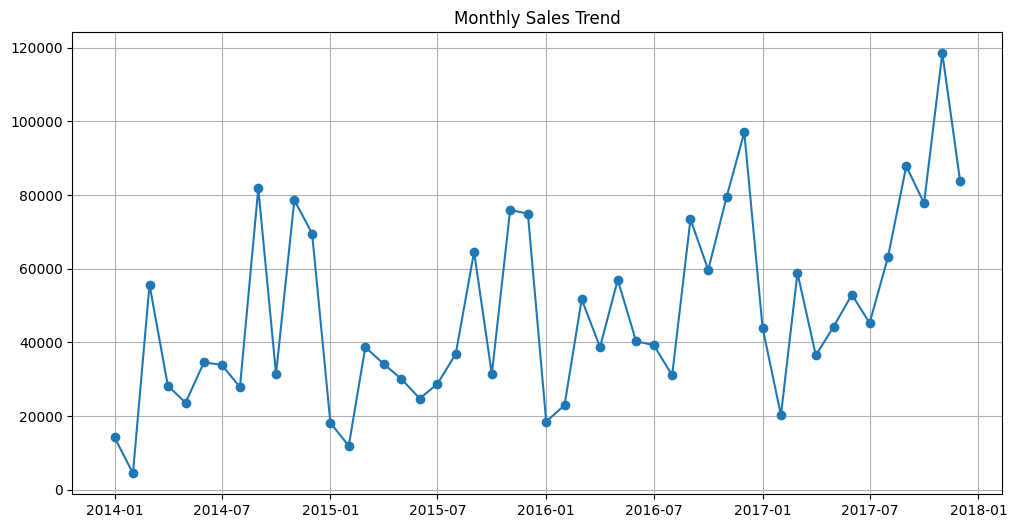

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(monthly_sales['Month'], monthly_sales['Total_Sales'], marker='o')
plt.title('Monthly Sales Trend')
plt.grid(True)
plt.show()

In [6]:
from statsmodels.tsa.stattools import adfuller

# Run the Augmented Dickey-Fuller test
result = adfuller(monthly_sales['Total_Sales'])

print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

if result[1] <= 0.05:
    print("Conclusion: Data is stationary (Ready for modeling)")
else:
    print("Conclusion: Data is non-stationary (We need to apply differencing)")

ADF Statistic: -4.493768
p-value: 0.000202
Conclusion: Data is stationary (Ready for modeling)


In [7]:
!pip install pmdarima
import pmdarima as pm

# Automatically find the best parameters for SARIMA
# m=12 because our data is monthly and repeats every 12 months
model = pm.auto_arima(monthly_sales['Total_Sales'], 
                      seasonal=True, m=12, 
                      suppress_warnings=True, 
                      stepwise=True)

print(model.summary())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 1.7 MB/s eta 0:00:00
                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                   48
Model:             SARIMAX(2, 1, 0)x(1, 0, 0, 12)   Log Likelihood                -531.846
Date:                            Tue, 12 May 2026   AIC                           1071.693
Time:                                    13:54:03   BIC                           1079.093
Sample:                                         0   HQIC                          1074.477
                                             - 48                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6248      0.216  

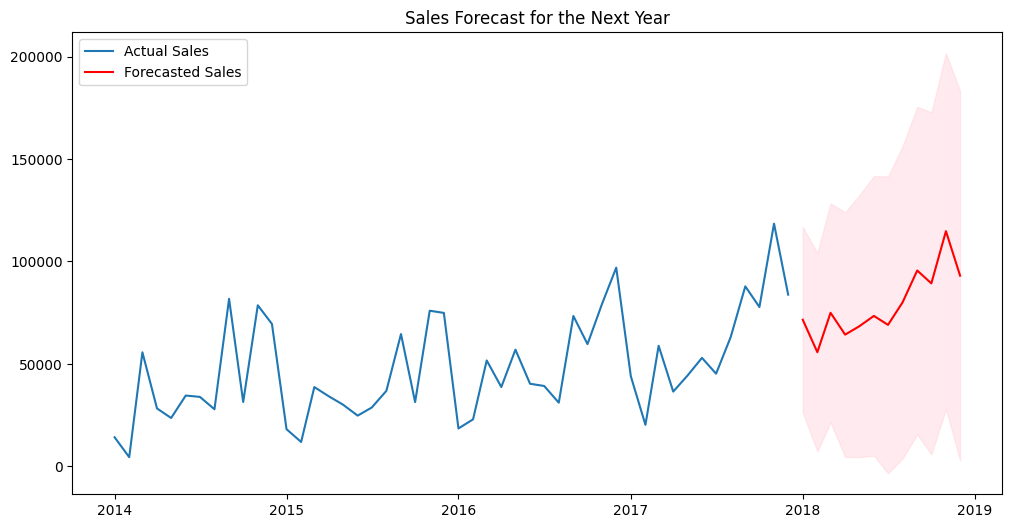

In [8]:
# Forecast the next 12 months
n_periods = 12
forecast, conf_int = model.predict(n_periods=n_periods, return_conf_int=True)

# Create a range of dates for the forecast
last_date = monthly_sales['Month'].iloc[-1]
forecast_dates = pd.date_range(last_date, periods=n_periods+1, freq='MS')[1:]

# Visualize the forecast
plt.figure(figsize=(12,6))
plt.plot(monthly_sales['Month'], monthly_sales['Total_Sales'], label='Actual Sales')
plt.plot(forecast_dates, forecast, label='Forecasted Sales', color='red')
plt.fill_between(forecast_dates, conf_int[:, 0], conf_int[:, 1], color='pink', alpha=0.3)
plt.title('Sales Forecast for the Next Year')
plt.legend()
plt.show()

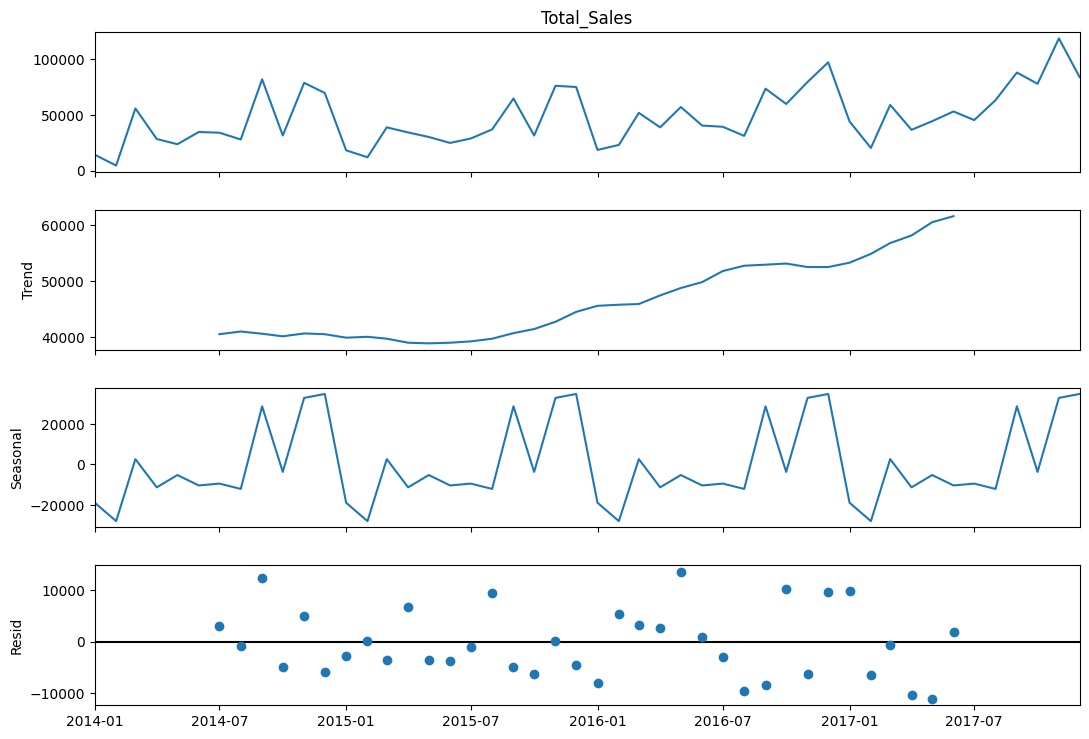

In [9]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Decompose the monthly sales
# We use 'additive' because the seasonal spikes look relatively consistent in height
decomposition = seasonal_decompose(monthly_sales.set_index('Month')['Total_Sales'], model='additive')

fig = decomposition.plot()
fig.set_size_inches(12, 8)

Root Mean Squared Error (RMSE): 23373.66
Average Monthly Sales in Test Set: 61101.27
Accuracy Metric (Error %): 38.25%


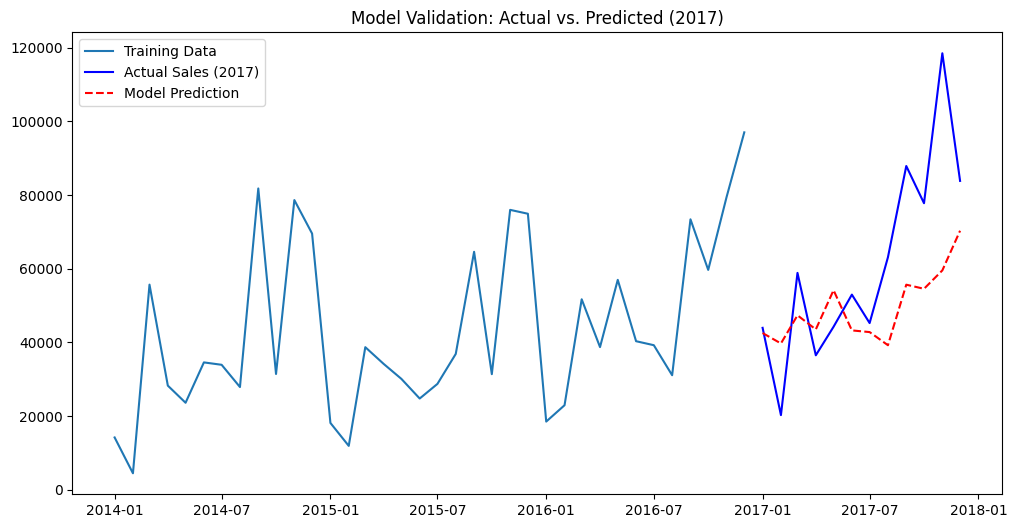

In [10]:
from sklearn.metrics import mean_squared_error
import numpy as np

# 1. Split the data: Use first 36 months for training, last 12 for testing
train = monthly_sales.iloc[:-12]
test = monthly_sales.iloc[-12:]

# 2. Fit the model on the training set only
test_model = pm.auto_arima(train['Total_Sales'], seasonal=True, m=12, suppress_warnings=True)

# 3. Forecast for the test period (12 months)
predictions = test_model.predict(n_periods=12)

# 4. Calculate the Error Rate (RMSE)
rmse = np.sqrt(mean_squared_error(test['Total_Sales'], predictions))
mean_sales = test['Total_Sales'].mean()

print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Average Monthly Sales in Test Set: {mean_sales:.2f}")
print(f"Accuracy Metric (Error %): {(rmse/mean_sales)*100:.2f}%")

# 5. Visualize the comparison
plt.figure(figsize=(12,6))
plt.plot(train['Month'], train['Total_Sales'], label='Training Data')
plt.plot(test['Month'], test['Total_Sales'], label='Actual Sales (2017)', color='blue')
plt.plot(test['Month'], predictions, label='Model Prediction', color='red', linestyle='--')
plt.title('Model Validation: Actual vs. Predicted (2017)')
plt.legend()
plt.show()

In [11]:
# Apply Log Transform
monthly_sales['Log_Sales'] = np.log(monthly_sales['Total_Sales'])

# Train the model on Log_Sales instead of Total_Sales
# Then, when you predict, use np.exp() to bring the numbers back to dollars

In [12]:
# Example: Filter for just Technology items
tech_sales = df[df['Category'] == 'Technology'].set_index('Order Date')['Sales'].resample('MS').sum()

In [13]:
from prophet import Prophet

# Prepare data for Prophet
df_prophet = monthly_sales.rename(columns={'Month': 'ds', 'Total_Sales': 'y'})

# Split data (matching your previous 3-year train / 1-year test split)
train_prophet = df_prophet.iloc[:-12]
test_prophet = df_prophet.iloc[-12:]

In [14]:
# Initialize model with yearly seasonality and holiday effects
model_p = Prophet(yearly_seasonality=True, interval_width=0.95)
model_p.add_country_holidays(country_name='US')

# Fit the model
model_p.fit(train_prophet)

# Create a dataframe for the 12 months of 2017
future = model_p.make_future_dataframe(periods=12, freq='MS')
forecast = model_p.predict(future)

13:54:08 - cmdstanpy - INFO - Chain [1] start processing
13:54:08 - cmdstanpy - INFO - Chain [1] done processing


New Prophet RMSE: 13314.31
New Accuracy Metric (Error %): 21.79%


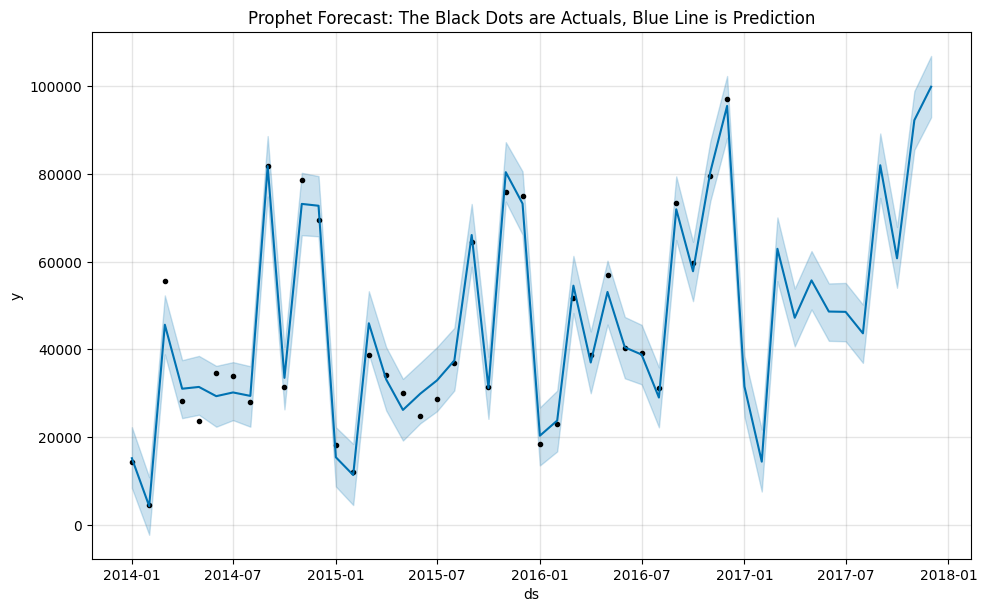

In [15]:
# Extract the predictions for the test period
prophet_pred = forecast.iloc[-12:][['ds', 'yhat']]

# Calculate RMSE
rmse_p = np.sqrt(mean_squared_error(test_prophet['y'], prophet_pred['yhat']))
mean_sales = test_prophet['y'].mean()

print(f"New Prophet RMSE: {rmse_p:.2f}")
print(f"New Accuracy Metric (Error %): {(rmse_p/mean_sales)*100:.2f}%")

# Visualize
fig1 = model_p.plot(forecast)
plt.title('Prophet Forecast: The Black Dots are Actuals, Blue Line is Prediction')
plt.show()

Prophet RMSE: 13314.31
Prophet Error %: 21.79%


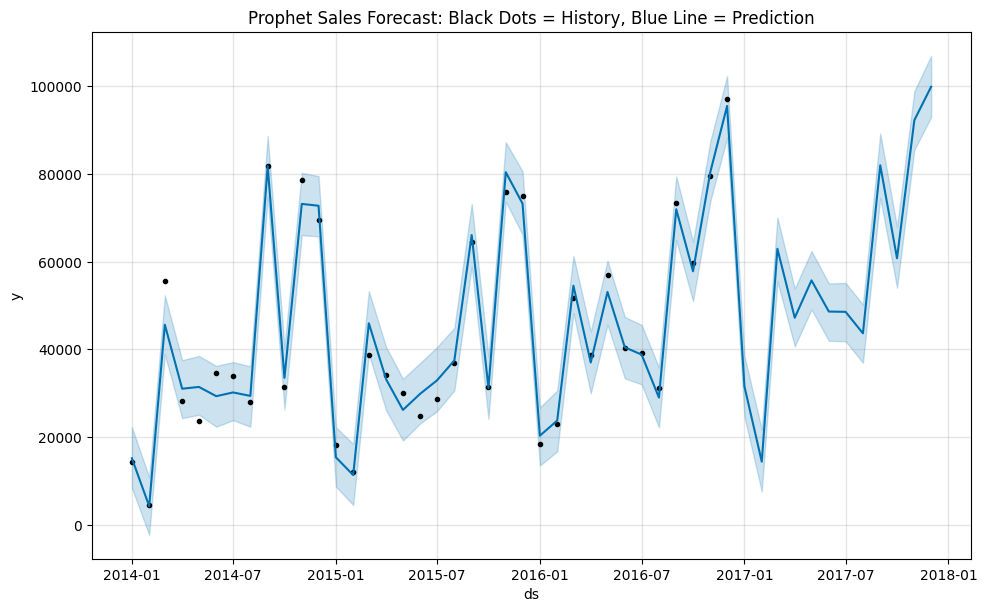

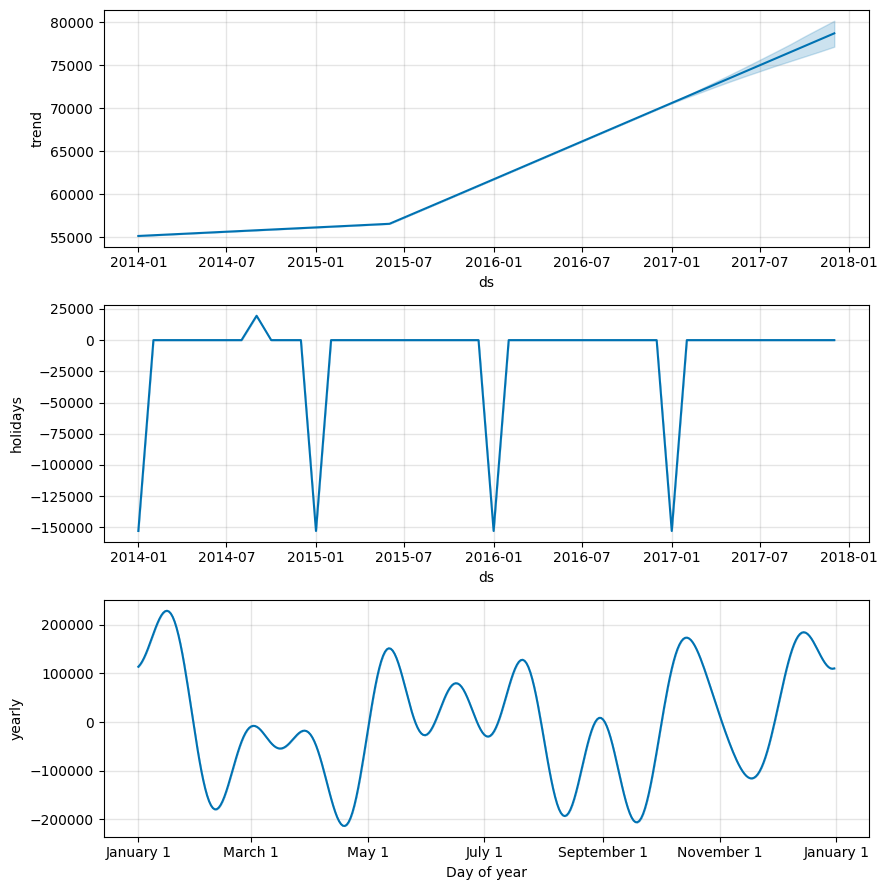

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import numpy as np

# 1. Compare the forecast with your actual 2017 test data
# We look at 'yhat', which is Prophet's version of 'Predicted Sales'
prophet_pred = forecast.iloc[-12:]['yhat']
actual_sales = test_prophet['y']

# 2. Calculate the new Error Metrics
rmse_p = np.sqrt(mean_squared_error(actual_sales, prophet_pred))
mean_val = actual_sales.mean()

print(f"Prophet RMSE: {rmse_p:.2f}")
print(f"Prophet Error %: {(rmse_p/mean_val)*100:.2f}%")

# 3. Visualize the Forecast
fig = model_p.plot(forecast)
plt.title("Prophet Sales Forecast: Black Dots = History, Blue Line = Prediction")
plt.show()

# 4. See the individual components (Trend, Holidays, Seasonality)
fig2 = model_p.plot_components(forecast)

13:54:10 - cmdstanpy - INFO - Chain [1] start processing
13:54:11 - cmdstanpy - INFO - Chain [1] done processing


--- Final 2018 Monthly Sales Forecast ---
     Month  Predicted_Sales
2018-01-01         46789.11
2018-02-01         33881.05
2018-03-01         73210.60
2018-04-01         57511.12
2018-05-01         58115.58
2018-06-01         59662.62
2018-07-01         59847.83
2018-08-01         64600.02
2018-09-01         95432.64
2018-10-01         69925.16
2018-11-01        112118.16
2018-12-01        103869.48


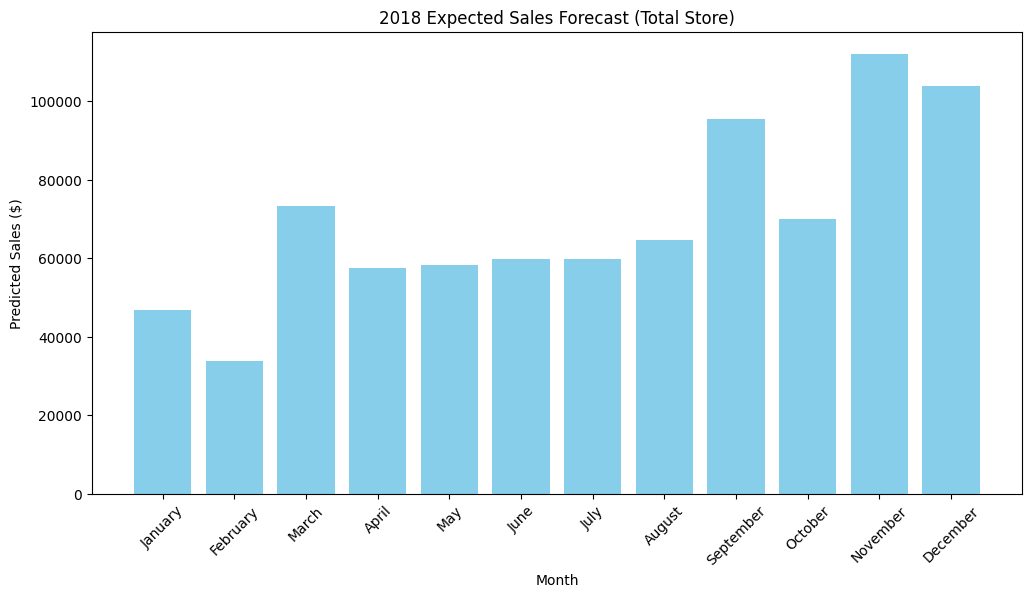

In [17]:
# 1. Re-train the model on the FULL dataset (2014-2017)
model_final = Prophet(yearly_seasonality=True, interval_width=0.95)
model_final.add_country_holidays(country_name='US')
model_final.fit(df_prophet) # Using the full df_prophet here

# 2. Create a 'future' dataframe that goes through the end of 2018
# We need 12 months beyond the end of our current data
future_2018 = model_final.make_future_dataframe(periods=12, freq='MS')
forecast_2018 = model_final.predict(future_2018)

# 3. Filter for just the new 2018 dates
export_df = forecast_2018[forecast_2018['ds'] >= '2018-01-01'][['ds', 'yhat']].copy()
export_df.columns = ['Month', 'Predicted_Sales']
export_df['Predicted_Sales'] = export_df['Predicted_Sales'].round(2)

# 4. Export and Display
export_df.to_csv('Superstore_2018_Sales_Forecast.csv', index=False)

print("--- Final 2018 Monthly Sales Forecast ---")
if export_df.empty:
    print("Error: DataFrame is still empty. Check the dates in your 'df_prophet' variable.")
else:
    print(export_df.to_string(index=False))

# 5. Final Visualization for 2018
plt.figure(figsize=(12,6))
plt.bar(export_df['Month'].dt.strftime('%B'), export_df['Predicted_Sales'], color='skyblue')
plt.title('2018 Expected Sales Forecast (Total Store)')
plt.xlabel('Month')
plt.ylabel('Predicted Sales ($)')
plt.xticks(rotation=45)
plt.show()